In [272]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [273]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [274]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [275]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\823630121.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\823630121.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\823630121.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

<Axes: xlabel='method', ylabel='rmse'>

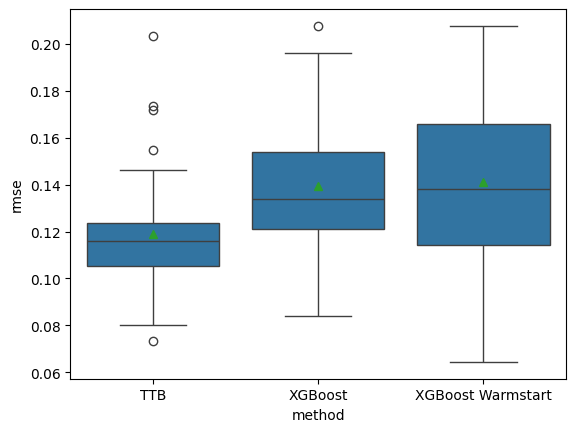

In [276]:
sub_name = 'location'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/xgb_naive.csv')
# naive_xgboost_data = data
# naive_xgboost_data['method'] = 'Naïve XGBoost'

# best_naive_XGBoost, lk = topk_per_d_per_method(
#     naive_xgboost_data,
# ['v', 'target_tree_size'], k=nr_of_seeds
# )
# best_naive_XGBoost['method'] = 'Naïve XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
#df = pd.concat([df, best_naive_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [277]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\3404690135.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\3404690135.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_26716\3404690135.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [278]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
1612,0.1,2.0,2.0,0.01,0.5,0.118838,0.092848,30,882.0,400.0,0.107112,0.086775,0.125652,0.085791,TransferTreeBoost
2016,0.1,1.0,2.0,0.01,0.5,0.119080,0.093930,30,888.0,400.0,0.085641,0.069597,0.118209,0.095850,TransferTreeBoost
1395,0.1,1.0,2.0,0.01,0.9,0.119320,0.094848,30,879.0,400.0,0.100721,0.079336,0.128576,0.105651,TransferTreeBoost
55,0.1,2.0,1.0,0.05,0.9,0.119445,0.094635,30,860.0,400.0,0.126347,0.103877,0.078268,0.060136,TransferTreeBoost
1041,0.1,2.0,2.0,0.00,0.5,0.119606,0.094066,30,874.0,400.0,0.137201,0.092249,0.123968,0.095296,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,0.1,2.0,1.0,0.05,0.1,0.138080,0.109321,30,865.0,400.0,0.103259,0.074534,0.112865,0.091671,TransferTreeBoost
1243,0.1,3.0,1.0,0.01,0.5,0.140044,0.108646,30,877.0,400.0,0.132054,0.108527,0.130114,0.074379,TransferTreeBoost
790,0.1,3.0,1.0,0.00,0.5,0.142752,0.110334,30,870.0,400.0,0.107776,0.091052,0.134729,0.105368,TransferTreeBoost
1645,0.1,1.0,1.0,0.05,0.1,0.143404,0.112173,30,882.0,400.0,0.115706,0.087852,0.120986,0.082571,TransferTreeBoost


In [279]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,0.139436,0.110646,30,0,860.0,0.151014,0.110312,0.090754,0.064824,XGBoost
61,0.1,2.0,0.140165,0.111031,30,61,870.0,0.147110,0.114848,0.114068,0.105191,XGBoost
119,0.1,6.0,0.144937,0.112067,30,119,879.0,0.127436,0.099915,0.204975,0.174904,XGBoost
116,0.1,3.0,0.145107,0.112292,30,116,879.0,0.121059,0.097931,0.208280,0.179013,XGBoost
27,0.1,4.0,0.145237,0.112022,30,27,864.0,0.203207,0.152225,0.146361,0.110594,XGBoost
4,0.1,5.0,0.145770,0.112865,30,4,860.0,0.179546,0.121454,0.097505,0.073569,XGBoost


In [280]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,0.141002,0.105889,30,2,860.0,0.173381,0.125147,0.087521,0.060616,XGBoost Warmstart
55,0.1,2.0,0.141708,0.107999,30,55,869.0,0.139465,0.100789,0.189681,0.146863,XGBoost Warmstart
108,0.1,1.0,0.143409,0.110439,30,108,878.0,0.122445,0.103691,0.140599,0.093613,XGBoost Warmstart
105,0.1,4.0,0.145194,0.108777,30,105,877.0,0.117242,0.091792,0.109455,0.071367,XGBoost Warmstart
28,0.1,5.0,0.145585,0.108534,30,28,864.0,0.212505,0.158151,0.153955,0.110585,XGBoost Warmstart
5,0.1,6.0,0.147898,0.109235,30,5,860.0,0.182199,0.128690,0.105496,0.073378,XGBoost Warmstart


In [281]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(14.7723186086926)